## Creating the Spark Session

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import os
import glob
import warnings
warnings.filterwarnings("ignore")

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = os.environ["PATH"] + r";C:\hadoop\bin"

#Create the spark session
spark = SparkSession.builder \
    .appName("MyApp") \
    .config("spark.driver.memory", "10g") \
    .getOrCreate()

## Reading the cleaned files

In [2]:
#Path to the folder with all the  files
files = glob.glob(os.path.join(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Dataset", "*.parquet"))

#Import failed a few times due to varying datatypes for the same column: passenger_count
#Decided to just convert all of them to doubles

dfs = [] #list for all our dataframes that we will eventually union
for f in files:
    d = spark.read.parquet(f)
    d = d.withColumn("passenger_count", col("passenger_count").cast("double"))
    dfs.append(d)

#Start with our first dataframe
df = dfs[0]

#Go through the list and append them
for d in dfs[1:]:
    df = df.unionByName(d, allowMissingColumns=True)

## EDA through SQL

In [3]:
"Count of the cleaned data"
df.count()

164790247

In [4]:
"A view of the data"

df.limit(10).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,trip_duration,average_trip_speed
0,2.0,2014-01-01 00:00:00,2014-01-01 00:10:00,1.0,3.65,1.0,114.0,79.0,2.0,12.5,0.00,13.50,0.166667,21.900000
1,2.0,2014-01-01 00:00:00,2014-01-01 00:06:00,2.0,2.52,1.0,166.0,142.0,1.0,8.5,1.50,11.00,0.100000,25.200000
2,2.0,2014-01-01 00:00:00,2014-01-01 00:04:00,2.0,0.52,1.0,233.0,162.0,2.0,4.5,0.00,5.50,0.066667,7.800000
3,2.0,2014-01-01 00:00:00,2014-01-01 00:28:00,3.0,6.20,1.0,236.0,144.0,1.0,23.0,4.70,28.70,0.466667,13.285714
4,2.0,2014-01-01 00:00:00,2014-01-01 00:12:00,1.0,2.62,1.0,151.0,42.0,2.0,11.5,0.00,12.50,0.200000,13.100000
5,2.0,2014-01-01 00:00:00,2014-01-01 00:06:00,1.0,0.95,1.0,229.0,162.0,2.0,6.0,0.00,7.00,0.100000,9.500000
6,2.0,2014-01-01 00:00:00,2014-01-01 00:06:00,2.0,1.53,1.0,52.0,33.0,1.0,7.0,1.88,9.88,0.100000,15.300000
7,1.0,2014-01-01 00:00:06,2014-01-01 00:10:11,1.0,6.00,1.0,138.0,134.0,2.0,18.0,0.00,19.00,0.168056,35.702479
8,1.0,2014-01-01 00:00:23,2014-01-01 00:20:52,1.0,7.70,1.0,209.0,143.0,1.0,25.0,6.00,32.00,0.341389,22.554923
9,1.0,2014-01-01 00:00:26,2014-01-01 00:05:52,1.0,1.50,1.0,164.0,229.0,1.0,6.5,2.25,9.75,0.090556,16.564417


In [5]:
"Creating our table that we will query"
df.createOrReplaceTempView("taxi_data")

In [6]:
"Query to get the number of trips"

trip_trends = spark.sql("""
    SELECT
        year(tpep_pickup_datetime) as trip_year, 
        count(VendorID) as number_of_trips, 
        count(CASE WHEN payment_type = 1 THEN 1 END) AS credit_card,
        count(CASE WHEN payment_type = 2 THEN 1 END) AS cash
    FROM taxi_data
    group by year(tpep_pickup_datetime)
    order by year(tpep_pickup_datetime) desc
""")
trip_trends.show()

+---------+---------------+-----------+--------+
|trip_year|number_of_trips|credit_card|    cash|
+---------+---------------+-----------+--------+
|     2025|        6877078|    5910739|  832574|
|     2024|        6925141|    5810304| 1010970|
|     2023|        6869526|    5628345| 1170451|
|     2022|        7034927|    5587222| 1413564|
|     2021|        5361829|    4129108| 1210238|
|     2020|        4312116|    3177390| 1112392|
|     2019|       15103572|   10933488| 4098092|
|     2018|       18566539|   12937090| 5534773|
|     2017|       18743675|   12646351| 5996600|
|     2016|       21531961|   14194280| 7243867|
|     2015|       23871925|   15013416| 8774545|
|     2014|       29591958|   17216831|12212506|
+---------+---------------+-----------+--------+



In [7]:
trends_pdf = trip_trends.toPandas().sort_values("trip_year")

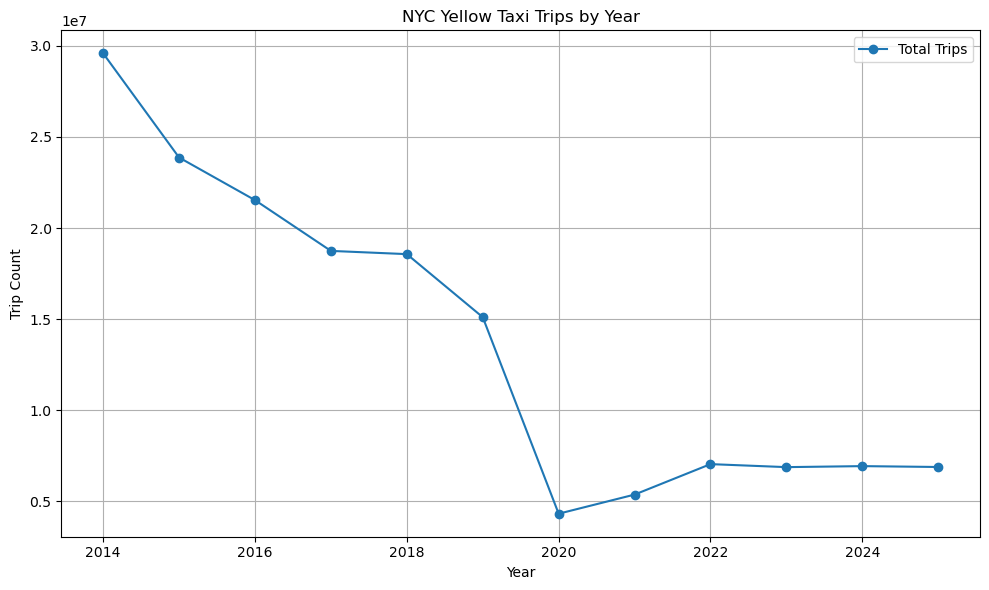

In [8]:
'Trip volume over time'

plt.figure(figsize=(10,6))
plt.plot(trends_pdf["trip_year"], trends_pdf["number_of_trips"], marker='o', label='Total Trips')
plt.title("NYC Yellow Taxi Trips by Year")
plt.xlabel("Year")
plt.ylabel("Trip Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Reports\trip_trends.png", dpi=300, bbox_inches='tight')

plt.show()

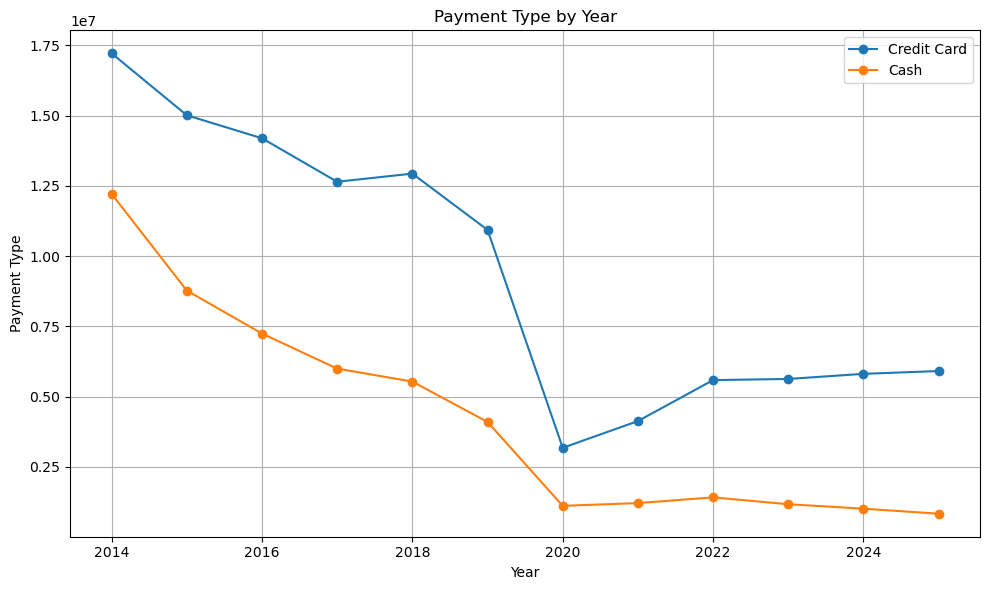

In [9]:
plt.figure(figsize=(10,6))
plt.plot(trends_pdf["trip_year"], trends_pdf["credit_card"], marker='o', label='Credit Card')
plt.plot(trends_pdf["trip_year"], trends_pdf["cash"], marker='o', label='Cash')
plt.title("Payment Type by Year")
plt.xlabel("Year")
plt.ylabel("Payment Type")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Reports\payment_trends.png", dpi=300, bbox_inches='tight')

plt.show()

In [10]:
peaks = spark.sql("""
    SELECT
    HOUR(tpep_pickup_datetime) as hour, 
    AVG(fare_amount) as average_fare, 
    AVG(average_trip_speed) as average_speed
    FROM taxi_data
    where (average_trip_speed >= 0 and average_trip_speed <= 55)
    group by HOUR(tpep_pickup_datetime)
    order by HOUR(tpep_pickup_datetime) desc
""")
peaks_data = peaks.toPandas().sort_values("hour")

In [11]:
peaks_data

,hour,average_fare,average_speed
23,0,13.615770,14.587775
22,1,12.948290,15.066357
21,2,12.621805,15.499903
20,3,13.154489,16.345116
19,4,15.308146,18.609623
18,5,16.323391,19.885381
17,6,13.387631,16.319205
16,7,12.519041,12.821618
15,8,12.653678,10.707691
14,9,12.822510,10.402870


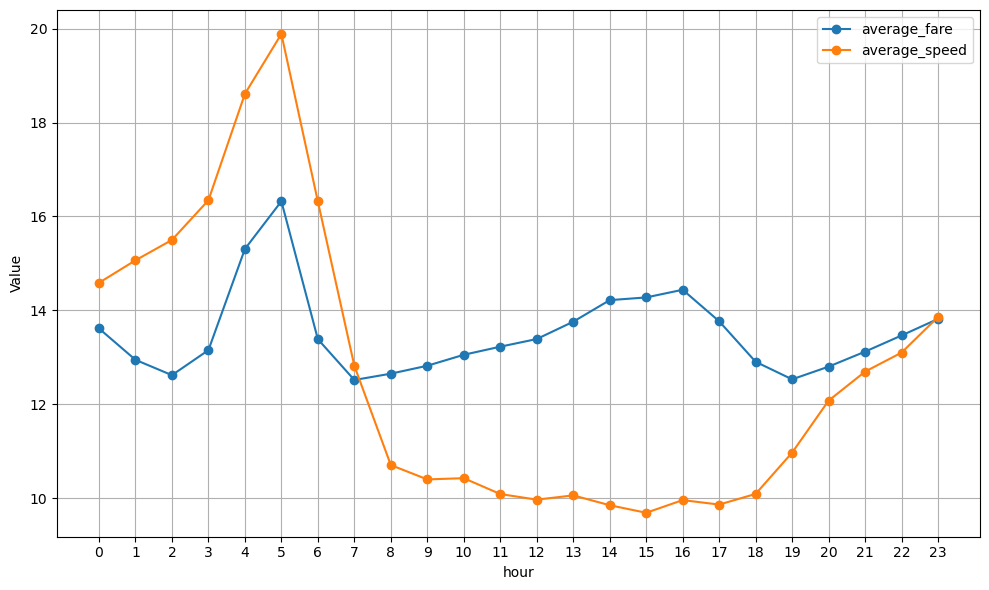

In [12]:
plt.figure(figsize=(10,6))
plt.plot(peaks_data["hour"], peaks_data["average_fare"], marker='o', label='average_fare')
plt.plot(peaks_data["hour"], peaks_data["average_speed"], marker='o', label='average_speed')
plt.xlabel("hour")
plt.ylabel("Value")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Reports\fare_trends.png", dpi=300, bbox_inches='tight')
plt.show()